# 02 Preprocessing and Feature Engineering

Create leakage-safe, per-ticker features and targets, then produce chronological train, validation, and test datasets. The scaler is fitted on training data only.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import ta
import torch
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_DIR / "sp500_stocks.csv", parse_dates=["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
df["LogReturn"] = df.groupby("Ticker")["Close"].transform(lambda prices: np.log(prices / prices.shift(1)))
display(df.head())

,Date,Close,High,Low,Open,Volume,Ticker,LogReturn
0,2005-01-03,0.946491,0.973708,0.936171,0.968773,691992000,AAPL,NaN
1,2005-01-04,0.956211,0.979092,0.941705,0.953968,1096810400,AAPL,0.010218
2,2005-01-05,0.964586,0.975802,0.957856,0.963987,680433600,AAPL,0.008720
3,2005-01-06,0.965334,0.970717,0.947089,0.967128,705555200,AAPL,0.000775
4,2005-01-07,1.035620,1.041304,0.968324,0.972062,2227450400,AAPL,0.070282


## Compute technical indicators within each ticker

In [3]:
def add_indicators(stock):
    stock = stock.sort_values("Date").copy()
    close, high, low, volume = stock["Close"], stock["High"], stock["Low"], stock["Volume"]
    for name, window in [("SMA_5", 5), ("SMA_20", 20), ("SMA_50", 50), ("SMA_200", 200)]:
        stock[name] = close.rolling(window).mean()
    stock["SMA_5_20_diff"] = (stock["SMA_5"] - stock["SMA_20"]) / stock["SMA_20"]
    stock["SMA_50_200_diff"] = (stock["SMA_50"] - stock["SMA_200"]) / stock["SMA_200"]
    stock["RSI"] = ta.momentum.RSIIndicator(close, window=14).rsi()
    macd = ta.trend.MACD(close, window_slow=26, window_fast=12, window_sign=9)
    stock["MACD"], stock["MACD_Signal"], stock["MACD_Histogram"] = macd.macd(), macd.macd_signal(), macd.macd_diff()
    bands = ta.volatility.BollingerBands(close, window=20, window_dev=2)
    stock["BB_width"] = (bands.bollinger_hband() - bands.bollinger_lband()) / bands.bollinger_mavg()
    stock["BB_pct"] = bands.bollinger_pband()
    stock["ATR_pct"] = ta.volatility.AverageTrueRange(high, low, close, window=14).average_true_range() / close
    obv = ta.volume.OnBalanceVolumeIndicator(close, volume).on_balance_volume()
    stock["OBV_z"] = (obv - obv.rolling(20).mean()) / obv.rolling(20).std()
    return stock


df = pd.concat([add_indicators(stock) for _, stock in df.groupby("Ticker", sort=False)], ignore_index=True)
display(df[["Ticker", "Date", "RSI", "MACD", "ATR_pct"]].head())

,Ticker,Date,RSI,MACD,ATR_pct
0,AAPL,2005-01-03,NaN,NaN,0.0
1,AAPL,2005-01-04,NaN,NaN,0.0
2,AAPL,2005-01-05,NaN,NaN,0.0
3,AAPL,2005-01-06,NaN,NaN,0.0
4,AAPL,2005-01-07,NaN,NaN,0.0


In [4]:
vix = pd.read_csv(DATA_DIR / "vix.csv", parse_dates=["Date"])[["Date", "Close"]].rename(columns={"Close": "VIX_Close"})
df = df.merge(vix, on="Date", how="left")
df["VIX_Close"] = df.groupby("Ticker")["VIX_Close"].ffill()

df["target_next_day_logreturn"] = df.groupby("Ticker")["LogReturn"].shift(-1)
df["target_5d_logreturn"] = df.groupby("Ticker")["Close"].transform(lambda prices: np.log(prices.shift(-5) / prices))
df["target_5d_direction"] = (df["target_5d_logreturn"] > 0).astype("Int64")

## Drop warm-up rows and create non-overlapping temporal splits

In [5]:
FEATURE_COLS = [
    "LogReturn", "SMA_5_20_diff", "SMA_50_200_diff", "RSI", "MACD", "MACD_Signal",
    "MACD_Histogram", "BB_width", "BB_pct", "ATR_pct", "OBV_z", "VIX_Close",
]
TARGET_COLS = ["target_next_day_logreturn", "target_5d_logreturn", "target_5d_direction"]
rows_before = len(df)
df_clean = df.dropna(subset=FEATURE_COLS + TARGET_COLS).reset_index(drop=True)
print(f"Dropped {rows_before - len(df_clean):,} warm-up or incomplete-target rows")
print(f"Modeling rows: {len(df_clean):,}")

unique_dates = np.sort(df_clean["Date"].unique())
train_start = unique_dates[int(len(unique_dates) * 0.70)]
test_start = unique_dates[int(len(unique_dates) * 0.85)]
train_df = df_clean[df_clean["Date"] < train_start].copy()
val_df = df_clean[(df_clean["Date"] >= train_start) & (df_clean["Date"] < test_start)].copy()
test_df = df_clean[df_clean["Date"] >= test_start].copy()
assert train_df["Date"].max() < val_df["Date"].min() < test_df["Date"].min()
for name, split in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name:10s} {len(split):>7,} rows | {split['Date'].min().date()} -> {split['Date'].max().date()}")

Dropped 10,200 warm-up or incomplete-target rows
Modeling rows: 248,873


Train      172,673 rows | 2005-10-17 -> 2019-11-27
Validation  38,100 rows | 2019-11-29 -> 2022-12-07
Test        38,100 rows | 2022-12-08 -> 2025-12-22


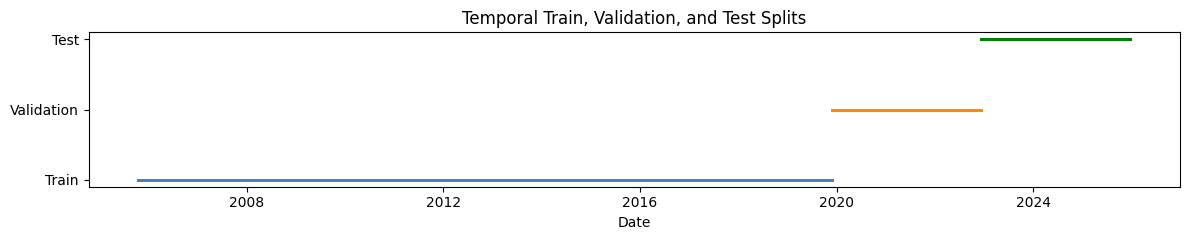

In [6]:
fig, ax = plt.subplots(figsize=(12, 2.5))
for name, split, color in [("Train", train_df, "steelblue"), ("Validation", val_df, "darkorange"), ("Test", test_df, "green")]:
    ax.scatter(split["Date"], [name] * len(split), s=1, color=color)
ax.set(title="Temporal Train, Validation, and Test Splits", xlabel="Date")
plt.tight_layout()
plt.show()

## Fit the scaler on training data only

In [7]:
scaler = StandardScaler()
scaler.fit(train_df[FEATURE_COLS])
for split in (train_df, val_df, test_df):
    split[FEATURE_COLS] = scaler.transform(split[FEATURE_COLS])

joblib.dump(scaler, MODELS_DIR / "feature_scaler.joblib")
joblib.dump(FEATURE_COLS, MODELS_DIR / "feature_cols.joblib")
train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)
print("Saved processed CSV splits and preprocessing metadata.")

Saved processed CSV splits and preprocessing metadata.


## PyTorch dataset examples

In [8]:
TARGET_COL = "target_next_day_logreturn"


class CrossSectionalDataset(Dataset):
    def __init__(self, frame, feature_cols, target_col):
        self.x = torch.tensor(frame[feature_cols].to_numpy(np.float32))
        self.y = torch.tensor(frame[target_col].to_numpy(np.float32)).unsqueeze(1)

    def __len__(self): return len(self.x)
    def __getitem__(self, index): return self.x[index], self.y[index]


train_loader = DataLoader(CrossSectionalDataset(train_df, FEATURE_COLS, TARGET_COL), batch_size=64, shuffle=True)
xb, yb = next(iter(train_loader))
print(f"Cross-sectional batch: X={tuple(xb.shape)}, y={tuple(yb.shape)}")

Cross-sectional batch: X=(64, 12), y=(64, 1)


In [9]:
class SequenceDataset(Dataset):
    def __init__(self, frame, feature_cols, target_col, sequence_length=60):
        self.samples = []
        for _, stock in frame.sort_values(["Ticker", "Date"]).groupby("Ticker", sort=False):
            features = stock[feature_cols].to_numpy(np.float32)
            targets = stock[target_col].to_numpy(np.float32)
            for end in range(sequence_length - 1, len(stock)):
                self.samples.append((features[end-sequence_length+1:end+1], targets[end]))

    def __len__(self): return len(self.samples)
    def __getitem__(self, index):
        window, target = self.samples[index]
        return torch.from_numpy(window), torch.tensor(target)


sequence_data = SequenceDataset(train_df, FEATURE_COLS, TARGET_COL)
sequence_loader = DataLoader(sequence_data, batch_size=64, shuffle=True)
xb, yb = next(iter(sequence_loader))
print(f"Sequence batch: X={tuple(xb.shape)}, y={tuple(yb.shape)}")

Sequence batch: X=(64, 60, 12), y=(64,)
